# Phase 4 : Can the Optimum Be Trusted?

**Project:** A data-driven surrogate for airfoil shape optimization, built on the AirfRANS benchmark

**Author:** Muhammad Uns Haider Shah

## Objective
Phase 3 produced optimised airfoils. This notebook asks whether those optima are real features of the flow physics or artefacts of a surrogate trained on 160 simulations. No new CFD is available here, so trust is assessed with four independent checks:

1. **Position relative to the data.** How far the optima sit from the training designs, and what the Gaussian process predictive variance says there compared with the rest of the design space.
2. **Stability under resampling.** The direct surrogate is retrained on random subsets of the training cases and the optimization is repeated. If the optimum moves substantially, it is a property of the sample rather than of the physics.
3. **Leaving the training envelope.** The surrogate is evaluated on the AirfRANS Reynolds-number and angle-of-attack **extrapolation** splits, and the growth of its error is compared with the growth of its own predicted uncertainty. A surrogate that knows when to stop being trusted is far more useful than one that does not.
4. **A documented failure.** The case in the training data whose drag the surrogate misses most, examined in detail: which flow mechanism causes it, how sparsely that regime is represented, and whether any uncertainty measure flags it.

**Runtime:** Google Colab (GPU optional). Requires the Drive dataset cache and the Phase 1, 2, 2b and 3 outputs.

## 1. Environment

In [ ]:
# pyvista is pinned: 0.49+ requires a newer IPython than the Colab runtime provides
!pip install -q airfrans "pyvista==0.48.0" "vtk<9.7"
import airfrans as af
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch, torch.nn as nn
import os, glob, json, time, gc

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE, '|', torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'NO GPU: change the runtime type')
from scipy.spatial import cKDTree
from scipy.stats import spearmanr
from airfrans.naca_generator import camber_line, naca_generator
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from scipy.optimize import minimize
from scipy.stats import qmc, norm
from airfrans.naca_generator import naca_generator, camber_line
import joblib, warnings
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from scipy.optimize import minimize
from scipy.stats import qmc, spearmanr
from airfrans.naca_generator import naca_generator, camber_line
import joblib, warnings

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.0/273.0 kB 17.4 MB/s eta 0:00:00
device: cpu | NO GPU: change the runtime type


## 2. Configuration

In [ ]:
TRUST = dict(
    seed         = 0,
    n_subsets    = 8,        # retraining repetitions
    subset_frac  = 0.8,      # fraction of training cases per subset
    n_members    = 5,        # ensemble members per subset (fewer than Phase 2b, for speed)
    epochs       = 3000,
    lr           = 3e-3,
    n_starts     = 8,        # multi-start count when re-optimising
    max_cases    = 300,      # cap per extrapolation split (sampled at random if larger)
    min_group    = 5,        # smallest group size reported in the band study
)
np.random.seed(TRUST['seed']); torch.manual_seed(TRUST['seed'])

## 3. Dataset and earlier artefacts

In [ ]:
import shutil, zipfile
from google.colab import drive

USE_DRIVE = True
DRIVE_DIR = '/content/drive/MyDrive/airfrans'
DRIVE_ZIP = f'{DRIVE_DIR}/Dataset.zip'
ROOT_DL   = '/content/airfrans_data'
LOCAL_ZIP = f'{ROOT_DL}/Dataset.zip'

def have_data():
    return bool(glob.glob(f'{ROOT_DL}/**/manifest.json', recursive=True))

def gb(path):
    return os.path.getsize(path) / 1e9

if USE_DRIVE:
    drive.mount('/content/drive')
    os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(ROOT_DL, exist_ok=True)

if have_data():
    print('Dataset already extracted on this machine.')
elif USE_DRIVE and os.path.exists(DRIVE_ZIP):
    print(f'Copying {gb(DRIVE_ZIP):.1f} GB zip from Drive (unzipping from local disk is much faster)...')
    shutil.copy(DRIVE_ZIP, LOCAL_ZIP)
    print('Unzipping...')
    with zipfile.ZipFile(LOCAL_ZIP) as z:
        z.extractall(ROOT_DL)
else:
    print('No cached copy found. Downloading from the AirfRANS server (slow, one time only)...')
    af.dataset.download(root=ROOT_DL, file_name='Dataset', unzip=True, OpenFOAM=False)

# Cache to Drive if it isn't there yet. This only runs after a successful unzip,
# so a broken or partial download never gets saved.
if USE_DRIVE and os.path.exists(LOCAL_ZIP) and have_data():
    if not os.path.exists(DRIVE_ZIP) or gb(DRIVE_ZIP) != gb(LOCAL_ZIP):
        print(f'Saving {gb(LOCAL_ZIP):.1f} GB zip to Drive (10-20 min, one time only)...')
        shutil.copy(LOCAL_ZIP, DRIVE_ZIP)
    print(f'Drive copy OK: {gb(DRIVE_ZIP):.2f} GB  (local {gb(LOCAL_ZIP):.2f} GB)')

print('Data ready:', have_data())

Mounted at /content/drive
Copying 10.0 GB zip from Drive (unzipping from local disk is much faster)...
Unzipping...
Drive copy OK: 10.03 GB  (local 10.03 GB)
Data ready: True


In [ ]:
# The loader needs the folder that contains manifest.json. Find it rather than guessing.
ROOT = os.path.dirname(glob.glob(f'{ROOT_DL}/**/manifest.json', recursive=True)[0])
print('Dataset root:', ROOT)

# Free disk space: the zip is no longer needed locally once extracted
zip_path = f'{ROOT_DL}/Dataset.zip'
if os.path.exists(zip_path):
    os.remove(zip_path)

with open(f'{ROOT}/manifest.json') as f:
    manifest = json.load(f)
for k, v in manifest.items():
    print(f'{k:15s} {len(v):5d} simulations')

Dataset root: /content/airfrans_data/Dataset
full_train        800 simulations
scarce_train      200 simulations
reynolds_train    504 simulations
aoa_train         804 simulations
full_test         200 simulations
reynolds_test     496 simulations
aoa_test          196 simulations


In [ ]:
import numpy as np

def order_surface(pos, normals):
    """Return indices that walk the airfoil surface as a closed loop:
    upper surface leading edge -> trailing edge, then lower surface trailing edge -> leading edge.
    Works whichever way the normals point (inward or outward)."""
    g1 = np.where(normals[:, 1] < 0)[0]
    g2 = np.where(normals[:, 1] >= 0)[0]
    # The upper-surface group is the one sitting higher on average
    upper, lower = (g1, g2) if pos[g1, 1].mean() > pos[g2, 1].mean() else (g2, g1)
    upper = upper[np.argsort(pos[upper, 0])]     # LE -> TE
    lower = lower[np.argsort(-pos[lower, 0])]    # TE -> LE
    return np.concatenate([upper, lower]), len(upper)

def pressure_force_coefficients(pos, normals, p, u_inf, aoa_rad):
    """Integrate surface pressure (kinematic, p/rho) to pressure-only lift and drag coefficients.
    pos, normals, p: surface nodes only. Returns (cd_p, cl_p)."""
    idx, _ = order_surface(pos, normals)
    P, N, pp = pos[idx], normals[idx], p[idx].ravel()
    # Length "owned" by each node = half of each neighbouring segment on the closed loop
    seg = np.linalg.norm(np.roll(P, -1, axis=0) - P, axis=1)
    L = 0.5 * (seg + np.roll(seg, 1))
    # Make normals point OUT of the body: on average they should point away from the centroid
    sign = np.sign(np.mean(np.sum((P - P.mean(axis=0)) * N, axis=1)))
    n_out = sign * N / np.linalg.norm(N, axis=1, keepdims=True)
    F = -(pp[:, None] * n_out * L[:, None]).sum(axis=0)       # force / rho
    drag_dir = np.array([np.cos(aoa_rad), np.sin(aoa_rad)])
    lift_dir = np.array([-np.sin(aoa_rad), np.cos(aoa_rad)])
    q = 0.5 * u_inf**2
    return F @ drag_dir / q, F @ lift_dir / q

def parse_name(name):
    """AirfRANS names look like airFoil2D_SST_<Uinf>_<AoA deg>_<NACA params...>"""
    parts = name.split('_')
    u_inf, aoa = float(parts[2]), float(parts[3])
    naca = [float(v) for v in parts[4:]]
    return u_inf, aoa, naca


In [ ]:
D = DRIVE_DIR if USE_DRIVE else '/content'
P1_DIR, P2_DIR, P2B_DIR, P3_DIR = (os.path.join(D, p) for p in ('phase1', 'phase2', 'phase2b', 'phase3'))
OUT_DIR = os.path.join(D, 'phase4')
os.makedirs(OUT_DIR, exist_ok=True)

ens_ck = torch.load(f'{P2B_DIR}/force_ensemble.pt', map_location=DEVICE, weights_only=False)
gp_ck = joblib.load(f'{P2B_DIR}/force_gp.joblib')
optima = np.load(f'{P3_DIR}/optima.npz')
with open(f'{P3_DIR}/phase3_summary.json') as f:
    p3 = json.load(f)
OPT = p3['opt']
STATIONS = np.array(ens_ck['stations'])
G_NAMES = ['t'] + [f'yc@{x:g}' for x in STATIONS]
IN_NAMES = G_NAMES + ['aoa', 're_M']
S = {k: np.array(v) for k, v in ens_ck['stats'].items() if k in ('xm', 'xs', 'ym', 'ys')}

family = lambda n: '4-digit' if len(parse_name(n)[2]) == 3 else '5-digit'
train_forces = pd.read_csv(f'{P2B_DIR}/train_forces.csv')
test_forces = pd.read_csv(f'{P2_DIR}/test_forces.csv')
with open(f'{P1_DIR}/phase1_summary.json') as f:
    VAL_NAMES = set(json.load(f)['val_names'])
train_only = train_forces[~train_forces['name'].isin(VAL_NAMES)].reset_index(drop=True)
print(f"training cases {len(train_only)} | validation {len(VAL_NAMES)} | test {len(test_forces)}")
print(f"problem 1 optimum: {np.round(optima['p1_grad'], 3)}  (M, P, XX)")
print(f"problem 2 optimum: {np.round(optima['p2_grad'], 3)}  (M, P, XX, alpha)")

training cases 160 | validation 40 | test 200
problem 1 optimum: [ 5.082  6.945 12.   ]  (M, P, XX)
problem 2 optimum: [ 3.504  1.296 12.     4.402]  (M, P, XX, alpha)


## 4. Surrogates and parameterisation
The differentiable parameterisation and surrogate wrappers from Phase 3.

In [ ]:
ST = torch.tensor(STATIONS, dtype=torch.float64, device=DEVICE)

def descriptor_torch(design):
    # design: (..., 3) = [M (% chord), P (tenths), XX (% chord)] -> (..., 13) descriptor
    M, P, XX = design[..., 0:1], design[..., 1:2], design[..., 2:3]
    m, p, t = M / 100, P / 10, XX / 100
    x = ST.expand(*design.shape[:-1], len(ST))
    fore = (m / p ** 2) * (2 * p * x - x ** 2)
    aft = (m / (1 - p) ** 2) * ((1 - 2 * p) + 2 * p * x - x ** 2)
    y_c = torch.where(x < p, fore, aft)
    return torch.cat([t, y_c], dim=-1)


In [ ]:
class ForceMLP(nn.Module):
    def __init__(self, n_in, width):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_in, width), nn.SiLU(),
                                 nn.Linear(width, width), nn.SiLU(),
                                 nn.Linear(width, 2))
    def forward(self, x):
        return self.net(x)

ensemble = []
for st in ens_ck['states']:
    net = ForceMLP(len(IN_NAMES), ens_ck['width']).to(DEVICE).double()
    net.load_state_dict({k: v.double() for k, v in st.items()}); net.eval()
    ensemble.append(net)

xm, xs = (torch.tensor(S[k], dtype=torch.float64, device=DEVICE) for k in ('xm', 'xs'))
ym, ys = (torch.tensor(S[k], dtype=torch.float64, device=DEVICE) for k in ('ym', 'ys'))

def nn_forces(design, aoa, re=None):
    # design: (n, 3) tensor; aoa: (n, 1) tensor; returns CL, CD (tensors, differentiable)
    re = OPT['re'] if re is None else re
    g = descriptor_torch(design)
    re_col = torch.full_like(aoa, re / 1e6)
    X = (torch.cat([g, aoa, re_col], dim=-1) - xm) / xs
    P = torch.stack([net(X) for net in ensemble]).mean(0) * ys + ym
    return P[..., 0], torch.exp(P[..., 1])

def nn_np(x, aoa=None):
    # numpy interface: x = (n, 3) designs (+ aoa column if aoa is None)
    x = np.atleast_2d(x)
    d = torch.tensor(x[:, :3], dtype=torch.float64, device=DEVICE)
    a = torch.tensor(x[:, 3:4] if aoa is None else np.full((len(x), 1), aoa),
                     dtype=torch.float64, device=DEVICE)
    with torch.no_grad():
        cl, cd = nn_forces(d, a)
    return cl.cpu().numpy(), cd.cpu().numpy()

def gp_np(x, aoa=None):
    # Gaussian process: returns CL, CD and their standard deviations (log CD sd for drag)
    x = np.atleast_2d(x)
    g = np.stack([np.r_[d[2] / 100, camber_line(d[:2], STATIONS.copy())[0]] for d in x[:, :3]])
    a = x[:, 3:4] if aoa is None else np.full((len(x), 1), aoa)
    X = (np.hstack([g, a, np.full((len(x), 1), OPT['re'] / 1e6)]) - S['xm']) / S['xs']
    mu, sd = [], []
    for k, gp in enumerate(gp_ck['gps']):
        m, s = gp.predict(X, return_std=True)
        mu.append(m * S['ys'][k] + S['ym'][k]); sd.append(s * S['ys'][k])
    return mu[0], np.exp(mu[1]), sd[0], sd[1]

def grad_forces(x, aoa=None):
    # d(CL)/dx and d(log CD)/dx by automatic differentiation
    x = np.atleast_2d(x)
    d = torch.tensor(x[:, :3], dtype=torch.float64, device=DEVICE, requires_grad=True)
    a = torch.tensor(x[:, 3:4] if aoa is None else [[aoa]],
                     dtype=torch.float64, device=DEVICE, requires_grad=True)
    cl, cd = nn_forces(d, a)
    gcl = torch.autograd.grad(cl.sum(), [d, a], retain_graph=True)
    gcd = torch.autograd.grad(torch.log(cd).sum(), [d, a])
    # The angle is a design variable only in problem 2
    to_np = lambda g: np.r_[g[0].cpu().numpy().ravel(),
                            g[1].cpu().numpy().ravel() if aoa is None else []]
    return cl.item(), cd.item(), to_np(gcl), to_np(gcd)

## 5. Where do the optima sit?
Distances are measured in units of the design-variable ranges, so 0.1 means a tenth of the design space away. Both optima are compared with the typical spacing of the training designs themselves, and the Gaussian process uncertainty at the optima is placed in the distribution of its uncertainty over the whole design box.

In [ ]:
tr4 = np.array([parse_name(n)[2] for n in train_only['name'] if len(parse_name(n)[2]) == 3])
lo = np.array([p3['bounds'][k][0] for k in ('M', 'P', 'XX')])
hi = np.array([p3['bounds'][k][1] for k in ('M', 'P', 'XX')])
span = hi - lo

nn_dist = lambda x: np.sort(np.linalg.norm((tr4 - x[:3]) / span, axis=1))
own = np.array([np.sort(np.linalg.norm((tr4 - d) / span, axis=1))[1] for d in tr4])

pos_rows = []
for lab, x, aoa in (('problem 1 optimum', optima['p1_grad'], OPT['aoa_p1']),
                    ('problem 2 optimum', optima['p2_grad'], float(optima['p2_grad'][3]))):
    d = nn_dist(np.asarray(x, dtype=float))
    cl, cd, sd_cl, sd_logcd = gp_np(np.r_[np.asarray(x, dtype=float)[:3], aoa][None, :])
    pos_rows.append(dict(case=lab, nearest=d[0], mean_of_5_nearest=d[:5].mean(),
                         gp_sd_logCD=sd_logcd[0], gp_sd_CL=sd_cl[0]))
sampler = qmc.Sobol(3, scramble=True, seed=TRUST['seed'])
Xb = qmc.scale(sampler.random(4096), lo, hi)
_, _, sd_cl_b, sd_b = gp_np(np.c_[Xb, np.full(len(Xb), OPT['aoa_p1'])])
pos_rows.append(dict(case='design box (median)', nearest=np.median([nn_dist(x)[0] for x in Xb]),
                 mean_of_5_nearest=np.nan, gp_sd_logCD=np.median(sd_b), gp_sd_CL=np.median(sd_cl_b)))
pos_rows.append(dict(case='design box (90th percentile)', nearest=np.percentile([nn_dist(x)[0] for x in Xb], 90),
                 mean_of_5_nearest=np.nan, gp_sd_logCD=np.percentile(sd_b, 90),
                 gp_sd_CL=np.percentile(sd_cl_b, 90)))
position = pd.DataFrame(pos_rows).set_index('case')
print(position.to_string(float_format=lambda v: f'{v:.4f}'))
cl_opt1, cd_opt1, _, _ = gp_np(np.r_[np.asarray(optima['p1_grad'], dtype=float)[:3], OPT['aoa_p1']][None, :])
cd_opt1, cl_opt1 = cd_opt1[0], cl_opt1[0]
print(f'\ntypical spacing between training designs (nearest neighbour): median {np.median(own):.3f}')
print(f"predicted drag at the problem 1 optimum, +/-2 sd: "
      f"{np.exp(np.log(cd_opt1) - 2 * pos_rows[0]['gp_sd_logCD']):.5f} – "
      f"{np.exp(np.log(cd_opt1) + 2 * pos_rows[0]['gp_sd_logCD']):.5f}")

                              nearest  mean_of_5_nearest  gp_sd_logCD  gp_sd_CL
case                                                                           
problem 1 optimum              0.1302             0.2391       0.0114    0.0060
problem 2 optimum              0.2615             0.3314       0.0061    0.0026
design box (median)            0.1781                NaN       0.0070    0.0029
design box (90th percentile)   0.2863                NaN       0.0199    0.0081

typical spacing between training designs (nearest neighbour): median 0.158
predicted drag at the problem 1 optimum, +/-2 sd: 0.01227 – 0.01285


## 6. Does the optimum survive resampling?
The ensemble is retrained from scratch on random 80 % subsets of the training cases, and both optimization problems are solved again on each retrained surrogate with gradient-based multi-start search. The spread of the resulting designs measures how much of the optimum comes from the physics and how much from this particular set of 160 simulations.

In [ ]:
def features_np(names_or_designs, aoa, re, from_names=True):
    if from_names:
        G = np.stack([np.r_[parse_name(n)[2][-1] / 100, camber_line(np.array(parse_name(n)[2][:-1]), STATIONS.copy())[0]]
                      for n in names_or_designs])
    else:
        G = np.stack([np.r_[d[2] / 100, camber_line(np.array(d[:2]), STATIONS.copy())[0]] for d in names_or_designs])
    return np.hstack([G, np.asarray(aoa).reshape(-1, 1), np.asarray(re).reshape(-1, 1) / 1e6])

X_tr_all = features_np(train_only['name'], train_only['aoa'], train_only['re'])
Y_tr_all = np.c_[train_only['true_cl'], np.log(train_only['true_cd'])]

def train_ensemble(idx, seed0):
    Xt = torch.tensor((X_tr_all[idx] - S['xm']) / S['xs'], dtype=torch.float64, device=DEVICE)
    Yt = torch.tensor((Y_tr_all[idx] - S['ym']) / S['ys'], dtype=torch.float64, device=DEVICE)
    nets = []
    for m in range(TRUST['n_members']):
        torch.manual_seed(seed0 + m)
        net = ForceMLP(len(IN_NAMES), ens_ck['width']).to(DEVICE).double()
        opt_ = torch.optim.AdamW(net.parameters(), lr=TRUST['lr'], weight_decay=ens_ck['weight_decay'])
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt_, TRUST['epochs'])
        for _ in range(TRUST['epochs']):
            loss = ((net(Xt) - Yt) ** 2).mean()
            opt_.zero_grad(); loss.backward(); opt_.step(); sch.step()
        net.eval(); nets.append(net)
    return nets

def optimise_with(nets, problem):
    global ensemble
    keep, ensemble = ensemble, nets            # the wrappers close over `ensemble`
    try:
        bounds = list(zip(lo, hi)) + ([] if problem == 1 else [tuple(OPT['aoa_bounds'])])
        starts = qmc.scale(qmc.LatinHypercube(len(bounds), seed=TRUST['seed'] + problem).random(TRUST['n_starts']),
                           [b[0] for b in bounds], [b[1] for b in bounds])
        best = None
        for s in starts:
            if problem == 1:
                f = lambda x: (lambda cl, cd, gcl, gcd: (-cl / cd, -(gcl / cd) + (cl / cd) * gcd))(
                    *grad_forces(np.r_[x, OPT['aoa_p1']][None, :3], aoa=OPT['aoa_p1']))
                r = minimize(f, s, jac=True, method='L-BFGS-B', bounds=bounds, options=dict(maxiter=200))
            else:
                f = lambda x: (lambda cl, cd, gcl, gcd: (np.log(cd), gcd))(*grad_forces(x[None, :]))
                c = [dict(type='ineq',
                          fun=lambda x: grad_forces(x[None, :])[0] - OPT['cl_target'],
                          jac=lambda x: grad_forces(x[None, :])[2])]
                r = minimize(f, s, jac=True, method='SLSQP', bounds=bounds, constraints=c, options=dict(maxiter=200))
            if best is None or r.fun < best.fun:
                best = r
        return best.x, (-best.fun if problem == 1 else float(np.exp(best.fun)))
    finally:
        ensemble = keep

full1 = np.r_[optima['p1_grad'], OPT['aoa_p1']]
full2 = np.asarray(optima['p2_grad'], dtype=float)
ld_full = (lambda c: c[0][0] / c[1][0])(nn_np(full1[None, :3], aoa=OPT['aoa_p1']))
cd_full = nn_np(full2[None, :])[1][0]

def at_full_optimum(nets):
    # What this surrogate predicts for the designs found with all the data
    global ensemble
    keep, ensemble = ensemble, nets
    try:
        return ((lambda c: c[0][0] / c[1][0])(nn_np(full1[None, :3], aoa=OPT['aoa_p1'])),
                nn_np(full2[None, :])[1][0])
    finally:
        ensemble = keep

rs = np.random.default_rng(TRUST['seed'])
n_sub = int(TRUST['subset_frac'] * len(train_only))
rows, t0 = [], time.time()
print(f'retraining {TRUST["n_subsets"]} surrogates on {n_sub} cases each '
      f'({TRUST["n_members"]} members, {TRUST["epochs"]} steps); a few minutes in total')
for k in range(TRUST['n_subsets']):
    idx = rs.choice(len(train_only), n_sub, replace=False)
    nets = train_ensemble(idx, 5000 + 100 * k)
    x1, v1 = optimise_with(nets, 1)
    x2, v2 = optimise_with(nets, 2)
    ld_at_full, cd_at_full = at_full_optimum(nets)
    rows.append(dict(subset=k, M1=x1[0], P1=x1[1], XX1=x1[2], LD1=v1,
                     M2=x2[0], P2=x2[1], XX2=x2[2], alpha2=x2[3], CD2=v2,
                     LD_at_full_optimum=ld_at_full, CD_at_full_optimum=cd_at_full))
    print(f'  subset {k + 1}/{TRUST["n_subsets"]} | its own optimum: L/D {v1:.2f}, CD {v2:.5f} | '
          f'at the full-data optimum: L/D {ld_at_full:.2f}, CD {cd_at_full:.5f} | {time.time() - t0:.0f} s')
sub = pd.DataFrame(rows)
stats = sub.describe().loc[['mean', 'std', 'min', 'max']]
print('\nspread of the optima across retrained surrogates')
print(stats.drop(columns=['subset', 'LD_at_full_optimum', 'CD_at_full_optimum'])
           .to_string(float_format=lambda v: f'{v:.4f}'))
print(f'\nfull-data optimum: L/D {ld_full:.2f} (problem 1), CD {cd_full:.5f} (problem 2)')
print(f"design spread as a fraction of the design ranges: "
      f"M {sub['M1'].std() / span[0]:.3f}, P {sub['P1'].std() / span[1]:.3f}, XX {sub['XX1'].std() / span[2]:.3f}")

retraining 8 surrogates on 128 cases each (5 members, 3000 steps); a few minutes in total
  subset 1/8 | its own optimum: L/D 96.41, CD 0.00989 | at the full-data optimum: L/D 95.99, CD 0.00993 | 58 s
  subset 2/8 | its own optimum: L/D 94.96, CD 0.00981 | at the full-data optimum: L/D 94.88, CD 0.00989 | 87 s
  subset 3/8 | its own optimum: L/D 94.25, CD 0.00993 | at the full-data optimum: L/D 94.21, CD 0.01003 | 114 s
  subset 4/8 | its own optimum: L/D 94.85, CD 0.00977 | at the full-data optimum: L/D 94.85, CD 0.00985 | 145 s
  subset 5/8 | its own optimum: L/D 92.19, CD 0.01002 | at the full-data optimum: L/D 88.86, CD 0.01005 | 173 s
  subset 6/8 | its own optimum: L/D 92.08, CD 0.00986 | at the full-data optimum: L/D 83.57, CD 0.00986 | 202 s
  subset 7/8 | its own optimum: L/D 92.59, CD 0.01010 | at the full-data optimum: L/D 90.10, CD 0.01014 | 232 s
  subset 8/8 | its own optimum: L/D 93.09, CD 0.00980 | at the full-data optimum: L/D 92.83, CD 0.00978 | 260 s

spread of the o

**Do the retrained surrogates agree about the full-data optimum?** Each retrained surrogate evaluates both the design found with all the data and its own optimum. The gap between the two is the gain a designer would be chasing by re-optimising, and it is only meaningful if it exceeds the disagreement between surrogates.

In [ ]:
agree = sub.set_index('subset')[['LD_at_full_optimum', 'CD_at_full_optimum', 'LD1', 'CD2']]
agree = agree.assign(LD_gain_pct=100 * (agree['LD1'] / agree['LD_at_full_optimum'] - 1),
                     CD_gain_pct=100 * (1 - agree['CD2'] / agree['CD_at_full_optimum']))
print(agree.to_string(float_format=lambda v: f'{v:.5f}'))
print('\nLD_gain_pct / CD_gain_pct: how much better each retrained surrogate thinks its own')
print('optimum is than the full-data optimum. Compare this with the spread between surrogates.')
print(f"\nL/D at the full-data optimum: {agree['LD_at_full_optimum'].mean():.2f} "
      f"+/- {agree['LD_at_full_optimum'].std():.2f} across retrained surrogates "
      f"(full-data surrogate says {ld_full:.2f})")
print(f"CD at the full-data optimum: {agree['CD_at_full_optimum'].mean():.5f} "
      f"+/- {agree['CD_at_full_optimum'].std():.5f} (full-data surrogate says {cd_full:.5f})")

        LD_at_full_optimum  CD_at_full_optimum      LD1     CD2  LD_gain_pct  CD_gain_pct
subset                                                                                   
0                 95.98637             0.00993 96.41267 0.00989      0.44412      0.38808
1                 94.88223             0.00989 94.96150 0.00981      0.08355      0.84076
2                 94.20572             0.01003 94.24557 0.00993      0.04230      1.02164
3                 94.85194             0.00985 94.85195 0.00977      0.00001      0.85841
4                 88.85806             0.01005 92.19163 0.01002      3.75157      0.29055
5                 83.56683             0.00986 92.08104 0.00986     10.18850      0.05832
6                 90.10058             0.01014 92.58574 0.01010      2.75821      0.44163
7                 92.82609             0.00978 93.09400 0.00980      0.28861     -0.24747

LD_gain_pct / CD_gain_pct: how much better each retrained surrogate thinks its own
optimum is than 

## 7. Additional test cases, and the envelope question
The AirfRANS benchmark provides `reynolds` and `aoa` extrapolation splits, designed for models trained on a restricted band of operating conditions. The surrogates here were trained on the *scarce* split, which spans almost the full range of the dataset, so most of those cases are **inside** this model's envelope: they serve as several hundred extra test cases rather than as an extrapolation test. Genuine extrapolation is measured in Section 7b, by restricting the training band deliberately.

Reference coefficients are computed for these splits and cached. Two corrections are applied before any of them are used:

* **Leakage removal.** These splits are drawn from the same 1000 simulations as the `full` task, so a fraction of their cases belong to this model's own *scarce* training set. Those are identified by name and discarded; keeping them would report memorised values as accuracy.
* **Envelope flag.** The remainder are marked as inside or outside this model's training range of Reynolds number and incidence.

In [ ]:
env_aoa = (train_only['aoa'].min(), train_only['aoa'].max())
env_re = (train_only['re'].min(), train_only['re'].max())
print(f"training envelope: alpha {env_aoa[0]:.2f}–{env_aoa[1]:.2f}°, "
      f"Re {env_re[0] / 1e6:.2f}–{env_re[1] / 1e6:.2f} million")

CSV = f'{OUT_DIR}/extrapolation_forces.csv'
done = pd.read_csv(CSV) if os.path.exists(CSV) else pd.DataFrame()
wanted = []
for split in ('reynolds_test', 'aoa_test'):
    names = manifest.get(split)
    if not names:
        print(f'!! {split} not present in the manifest; skipping'); continue
    if len(names) > TRUST['max_cases']:
        names = list(np.random.default_rng(TRUST['seed']).choice(names, TRUST['max_cases'], replace=False))
    wanted += [(split, n) for n in names]
    print(f'{split}: {len(names)} cases')

have = set(done['name']) if len(done) else set()
todo = [(s, n) for s, n in wanted if n not in have]
rows, t0 = [], time.time()
for k, (split, name) in enumerate(todo):
    sim = af.Simulation(root=ROOT, name=name)
    u, aoa, _ = parse_name(name)
    (cd, _, _), (cl, _, _) = sim.force_coefficient(reference=True)
    rows.append(dict(name=name, split=split, u_inf=u, aoa=aoa, re=u / float(sim.NU),
                     family=family(name), true_cl=cl, true_cd=cd))
    if len(rows) == 20 or k == len(todo) - 1:
        done = pd.concat([done, pd.DataFrame(rows)], ignore_index=True); done.to_csv(CSV, index=False); rows = []
        print(f'  {k + 1}/{len(todo)} | {time.time() - t0:.0f} s')
extra = pd.read_csv(CSV) if os.path.exists(CSV) else pd.DataFrame()
# The reynolds/aoa splits are drawn from the same 1000 simulations as the full task, so some of
# their cases are in this model's own training set. Those must be removed before any evaluation.
if len(extra):
    seen = set(train_forces['name'])
    n_leak = extra['name'].isin(seen).sum()
    extra = extra[~extra['name'].isin(seen)].reset_index(drop=True)
    print(f'{n_leak} of these cases are in the training set (removed as leakage)')
print(f'{len(extra)} genuinely unseen extra cases available')

training envelope: alpha -4.79–14.84°, Re 2.03–6.00 million
reynolds_test: 300 cases
aoa_test: 196 cases
88 of these cases are in the training set (removed as leakage)
397 genuinely unseen extra cases available


In [ ]:
def evaluate(df, label):
    X = features_np(df['name'], df['aoa'], df['re'])
    G = X[:, :len(G_NAMES)]
    Xn = (X - S['xm']) / S['xs']
    with torch.no_grad():
        P = torch.stack([n(torch.tensor(Xn, dtype=torch.float64, device=DEVICE)) for n in ensemble]).mean(0)
    P = P.cpu().numpy() * S['ys'] + S['ym']
    mu, sd = [], []
    for j, gp in enumerate(gp_ck['gps']):
        m, s = gp.predict(Xn, return_std=True)
        mu.append(m * S['ys'][j] + S['ym'][j]); sd.append(s * S['ys'][j])
    out = df.copy()
    out['nn_cl'], out['nn_cd'] = P[:, 0], np.exp(P[:, 1])
    out['gp_cl'], out['gp_cd'] = mu[0], np.exp(mu[1])
    out['gp_sd_cl'], out['gp_sd_logcd'] = sd[0], sd[1]
    out['label'] = label
    out['outside'] = ((out['aoa'] < env_aoa[0]) | (out['aoa'] > env_aoa[1]) |
                      (out['re'] < env_re[0]) | (out['re'] > env_re[1]))
    return out

groups = [evaluate(test_forces[['name', 'aoa', 're', 'family', 'true_cl', 'true_cd']], 'test (in envelope)')]
for split in ('reynolds_test', 'aoa_test'):
    part = extra[extra['split'] == split] if len(extra) else pd.DataFrame()
    if len(part):
        groups.append(evaluate(part[['name', 'aoa', 're', 'family', 'true_cl', 'true_cd']], split))
ev = pd.concat(groups, ignore_index=True)

degr_rows = []
for (lab, outside), g in ev.groupby(['label', 'outside']):
    if len(g) < 5:
        continue
    r = dict(split=lab, outside_envelope=outside, n=len(g))
    for m in ('nn', 'gp'):
        r[f'{m}: CL abs err'] = (g[f'{m}_cl'] - g['true_cl']).abs().median()
        r[f'{m}: CD rel err'] = ((g[f'{m}_cd'] - g['true_cd']).abs() / g['true_cd']).median()
        r[f'{m}: rho_D'] = spearmanr(g[f'{m}_cd'], g['true_cd'])[0]
    r['gp: predicted sd(logCD)'] = g['gp_sd_logcd'].median()
    r['gp: actual |log CD err|'] = np.abs(np.log(g['gp_cd']) - np.log(g['true_cd'])).median()
    degr_rows.append(r)
degr = pd.DataFrame(degr_rows).set_index(['split', 'outside_envelope'])
print(degr.T.to_string(float_format=lambda v: f'{v:.4f}'))

split                   aoa_test         reynolds_test         test (in envelope)
outside_envelope           False   True          False   True               False
n                       136.0000 12.0000      238.0000 11.0000           197.0000
nn: CL abs err            0.0056  0.0045        0.0036  0.0028             0.0029
nn: CD rel err            0.0132  0.0143        0.0074  0.0122             0.0075
nn: rho_D                 0.9906  0.9930        0.9832  1.0000             0.9983
gp: CL abs err            0.0022  0.0026        0.0013  0.0020             0.0014
gp: CD rel err            0.0079  0.0030        0.0036  0.0044             0.0026
gp: rho_D                 0.9982  0.9930        0.9853  1.0000             0.9995
gp: predicted sd(logCD)   0.0100  0.0105        0.0064  0.0089             0.0061
gp: actual |log CD err|   0.0079  0.0030        0.0036  0.0044             0.0026


**Does the surrogate know when it is extrapolating?** The ratio of actual error to predicted uncertainty is the quantity that matters: if it stays near one outside the envelope, the uncertainty is informative and an optimizer can be told where to stop.

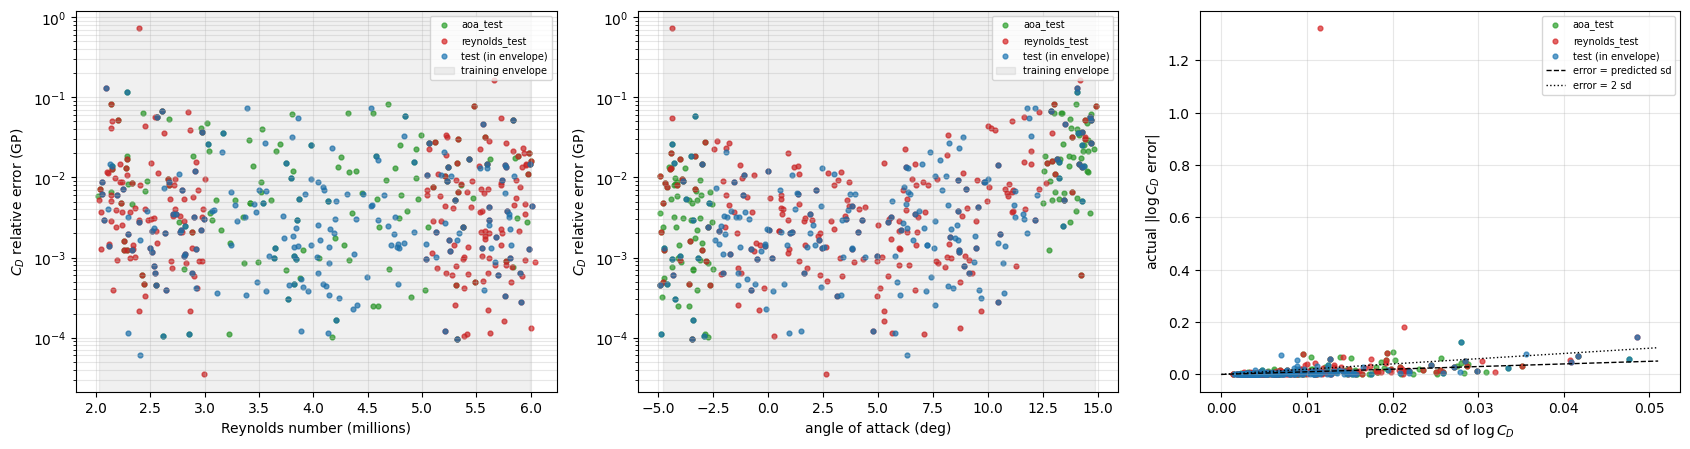

aoa_test               median error/sd ratio   0.76 | within 2 sd:  83.8 %
reynolds_test          median error/sd ratio   0.59 | within 2 sd:  90.0 %
test (in envelope)     median error/sd ratio   0.51 | within 2 sd:  90.5 %


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
colors = {'test (in envelope)': 'tab:blue', 'reynolds_test': 'tab:red', 'aoa_test': 'tab:green'}
for lab, g in ev.groupby('label'):
    c = colors.get(lab, 'gray')
    ax[0].scatter(g['re'] / 1e6, (g['gp_cd'] - g['true_cd']).abs() / g['true_cd'], s=12, c=c, label=lab, alpha=0.7)
    ax[1].scatter(g['aoa'], (g['gp_cd'] - g['true_cd']).abs() / g['true_cd'], s=12, c=c, label=lab, alpha=0.7)
    ax[2].scatter(g['gp_sd_logcd'], np.abs(np.log(g['gp_cd']) - np.log(g['true_cd'])), s=12, c=c, label=lab, alpha=0.7)
for a, (x0, x1) in ((ax[0], (env_re[0] / 1e6, env_re[1] / 1e6)), (ax[1], env_aoa)):
    a.axvspan(x0, x1, color='k', alpha=0.06, label='training envelope')
ax[0].set_xlabel('Reynolds number (millions)'); ax[1].set_xlabel('angle of attack (deg)')
for a in ax[:2]:
    a.set_ylabel('$C_D$ relative error (GP)'); a.set_yscale('log')
mx = ev['gp_sd_logcd'].max() * 1.05
ax[2].plot([0, mx], [0, mx], 'k--', lw=1, label='error = predicted sd')
ax[2].plot([0, mx], [0, 2 * mx], 'k:', lw=1, label='error = 2 sd')
ax[2].set_xlabel('predicted sd of $\\log C_D$'); ax[2].set_ylabel('actual $|\\log C_D$ error$|$')
for a in ax:
    a.grid(alpha=0.3, which='both'); a.legend(fontsize=7)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/extrapolation.png', dpi=150, bbox_inches='tight'); plt.show()

for lab, g in ev.groupby('label'):
    ratio = np.abs(np.log(g['gp_cd']) - np.log(g['true_cd'])) / g['gp_sd_logcd']
    print(f'{lab:22s} median error/sd ratio {np.median(ratio):6.2f} | '
          f'within 2 sd: {(ratio <= 2).mean() * 100:5.1f} %')

## 7b. Controlled extrapolation
To measure extrapolation properly, the training band is narrowed on purpose. For Reynolds number and then for angle of attack, the direct surrogates are retrained on the **central 60 %** of the training cases in that variable and tested on

* held-out cases **inside** the band (the interpolation reference), and
* cases **outside** the band, split into near and far bands by how far beyond the edge they lie.

The question is not only how fast accuracy decays, but whether the Gaussian process's own uncertainty grows to match. The ratio of actual error to predicted uncertainty is what an optimizer would rely on to know where to stop.

In [ ]:
def fit_gp_direct(X, Y):
    k = (ConstantKernel(1.0, (1e-2, 1e2))
         * Matern(length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-2, 1e3), nu=2.5)
         + WhiteKernel(1e-3, (1e-8, 1e0)))
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return [GaussianProcessRegressor(k, normalize_y=False, n_restarts_optimizer=2,
                                         random_state=TRUST['seed']).fit(X, Y[:, j]) for j in range(2)]

def band_study(var, col):
    v = train_forces[col].values
    inner_lo, inner_hi = np.percentile(v, [20, 80])
    inside = (v >= inner_lo) & (v <= inner_hi)
    rs2 = np.random.default_rng(TRUST['seed'])
    n_hold = int(np.clip(0.2 * inside.sum(), 5, inside.sum() // 3))
    holdout = rs2.permutation(np.where(inside)[0])[:n_hold]
    fit_idx = np.array([i for i in np.where(inside)[0] if i not in set(holdout)], dtype=int)

    X = features_np(train_forces['name'], train_forces['aoa'], train_forces['re'])
    Y = np.c_[train_forces['true_cl'], np.log(train_forces['true_cd'])]
    Xn = (X - S['xm']) / S['xs']; Yn = (Y - S['ym']) / S['ys']
    gps_b = fit_gp_direct(Xn[fit_idx], Yn[fit_idx])
    nets_b = train_ensemble_on(Xn[fit_idx], Yn[fit_idx], 12345)

    # distance beyond the band edge, in units of the band half-width
    half = (inner_hi - inner_lo) / 2
    beyond = np.maximum(inner_lo - v, v - inner_hi) / half
    groups = {'inside (held out)': np.isin(np.arange(len(v)), holdout),
              'outside, near (0–0.5)': (beyond > 0) & (beyond <= 0.5),
              'outside, far (> 0.5)': beyond > 0.5}

    out = []
    for lab, mask in groups.items():
        if mask.sum() < TRUST['min_group']:
            continue
        mu = np.c_[gps_b[0].predict(Xn[mask]), gps_b[1].predict(Xn[mask])] * S['ys'] + S['ym']
        with torch.no_grad():
            Pn = torch.stack([n(torch.tensor(Xn[mask], dtype=torch.float64, device=DEVICE))
                              for n in nets_b]).mean(0).cpu().numpy() * S['ys'] + S['ym']
        sd = np.c_[gps_b[0].predict(Xn[mask], return_std=True)[1],
                   gps_b[1].predict(Xn[mask], return_std=True)[1]] * S['ys']
        true_cl, true_cd = train_forces['true_cl'].values[mask], train_forces['true_cd'].values[mask]
        err_log = np.abs(mu[:, 1] - np.log(true_cd))
        out.append(dict(variable=var, group=lab, n=int(mask.sum()),
                        gp_CL_abs_err=np.median(np.abs(mu[:, 0] - true_cl)),
                        nn_CL_abs_err=np.median(np.abs(Pn[:, 0] - true_cl)),
                        gp_CD_rel_err=np.median(np.abs(np.exp(mu[:, 1]) - true_cd) / true_cd),
                        nn_CD_rel_err=np.median(np.abs(np.exp(Pn[:, 1]) - true_cd) / true_cd),
                        gp_sd_logCD=np.median(sd[:, 1]),
                        err_over_sd=np.median(err_log / sd[:, 1])))
    return pd.DataFrame(out), (inner_lo, inner_hi), beyond

def train_ensemble_on(Xn, Yn, seed0):
    Xt = torch.tensor(Xn, dtype=torch.float64, device=DEVICE)
    Yt = torch.tensor(Yn, dtype=torch.float64, device=DEVICE)
    nets = []
    for m in range(TRUST['n_members']):
        torch.manual_seed(seed0 + m)
        net = ForceMLP(len(IN_NAMES), ens_ck['width']).to(DEVICE).double()
        o = torch.optim.AdamW(net.parameters(), lr=TRUST['lr'], weight_decay=ens_ck['weight_decay'])
        sc = torch.optim.lr_scheduler.CosineAnnealingLR(o, TRUST['epochs'])
        for _ in range(TRUST['epochs']):
            loss = ((net(Xt) - Yt) ** 2).mean()
            o.zero_grad(); loss.backward(); o.step(); sc.step()
        net.eval(); nets.append(net)
    return nets

bands = {}
tables = []
for var, col in (('Reynolds number', 're'), ('angle of attack', 'aoa')):
    tb, band, beyond = band_study(var, col)
    bands[col] = (band, beyond)
    tables.append(tb)
    print(f"{var}: training band {band[0]:.3g} – {band[1]:.3g} "
          f"({(beyond <= 0).sum()} cases inside, {(beyond > 0).sum()} outside)")
tables = [t for t in tables if len(t)]
band_table = (pd.concat(tables, ignore_index=True).set_index(['variable', 'group']) if tables
              else pd.DataFrame(columns=['gp_CD_rel_err', 'gp_sd_logCD', 'err_over_sd']))
print()
print(band_table.T.to_string(float_format=lambda v: f'{v:.4f}') if len(band_table)
      else 'not enough cases per group to report; lower TRUST["min_group"] or widen the bands')

Reynolds number: training band 2.79e+06 – 5.04e+06 (120 cases inside, 80 outside)
angle of attack: training band -1.02 – 10.6 (120 cases inside, 80 outside)

variable        Reynolds number                                              angle of attack                                           
group         inside (held out) outside, near (0–0.5) outside, far (> 0.5) inside (held out) outside, near (0–0.5) outside, far (> 0.5)
n                       24.0000               52.0000              28.0000           24.0000               65.0000              15.0000
gp_CL_abs_err            0.0014                0.0013               0.0029            0.0008                0.0021               0.0104
nn_CL_abs_err            0.0038                0.0099               0.0135            0.0023                0.0082               0.0290
gp_CD_rel_err            0.0083                0.0126               0.0244            0.0033                0.0051               0.0400
nn_CD_rel_err            0

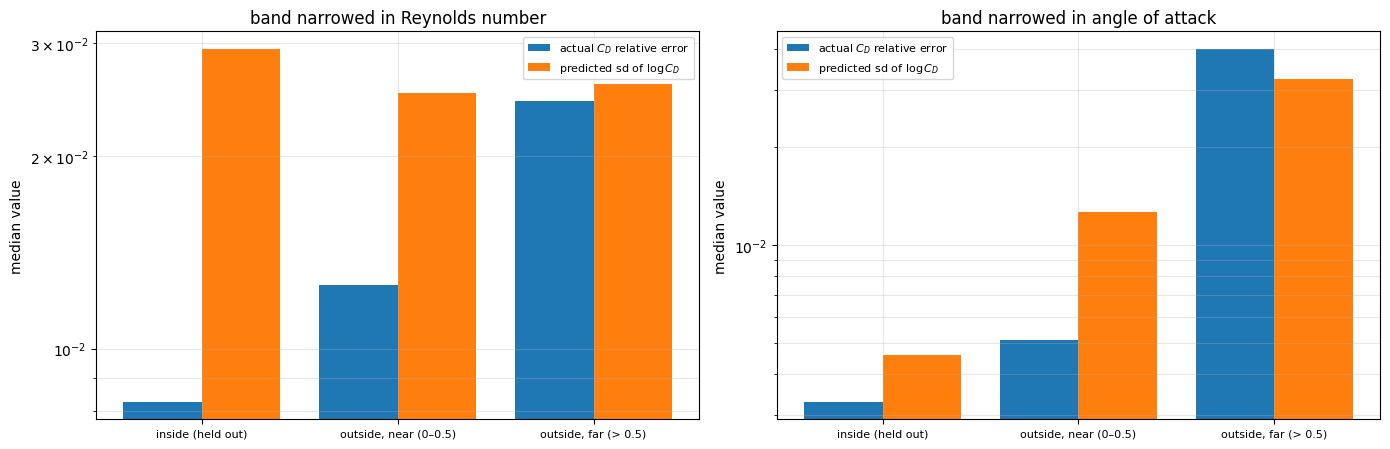

when the two bars are comparable, the predicted uncertainty is a usable warning;
when the error bar is far taller, the surrogate is confidently wrong.


In [ ]:
present = [] if not len(band_table) else [v for v in ('Reynolds number', 'angle of attack')
                                           if v in band_table.index.get_level_values(0)]
fig, ax = plt.subplots(1, max(1, len(present)), figsize=(7 * max(1, len(present)), 4.6), squeeze=False)
ax = ax.ravel()
for a, var in zip(ax, present):
    tb = band_table.loc[var]
    xs = np.arange(len(tb))
    a.bar(xs - 0.2, tb['gp_CD_rel_err'], 0.4, label='actual $C_D$ relative error')
    a.bar(xs + 0.2, tb['gp_sd_logCD'], 0.4, label='predicted sd of $\\log C_D$')
    a.set_xticks(xs); a.set_xticklabels(tb.index, fontsize=8)
    a.set_yscale('log'); a.set_ylabel('median value'); a.set_title(f'band narrowed in {var}')
    a.grid(alpha=0.3, which='both'); a.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/controlled_extrapolation.png', dpi=150, bbox_inches='tight'); plt.show()
print('when the two bars are comparable, the predicted uncertainty is a usable warning;')
print('when the error bar is far taller, the surrogate is confidently wrong.')

## 8. The documented failure
The training case whose drag the surrogate misses most is examined directly: its flow field, its surface pressure, and what the uncertainty measures say about it. This is the clearest illustration of the regime where a surrogate of this kind must not be trusted.

In [ ]:
X_all = features_np(train_forces['name'], train_forces['aoa'], train_forces['re'])
Xn_all = (X_all - S['xm']) / S['xs']
mu_cd, sd_cd = gp_ck['gps'][1].predict(Xn_all, return_std=True)
pred_cd = np.exp(mu_cd * S['ys'][1] + S['ym'][1])
tf = train_forces.assign(gp_cd=pred_cd, gp_sd_logcd=sd_cd * S['ys'][1],
                         err=np.abs(np.log(pred_cd) - np.log(train_forces['true_cd'])))
worst = tf.sort_values('err', ascending=False).iloc[0]
print(worst[['name', 'aoa', 're', 'family', 'true_cd', 'true_cdp', 'true_cdv', 'true_cl',
             'gp_cd', 'gp_sd_logcd', 'err']].to_string(float_format=lambda v: f'{v:.5f}'))
print(f"\nratio of actual error to predicted sd: {worst['err'] / worst['gp_sd_logcd']:.1f}"
      f"  (a value far above 2 means the surrogate is confidently wrong)")
print(f"its drag is {worst['true_cd'] / train_forces['true_cd'].median():.1f}x the training median, "
      f"and {worst['true_cdp'] / worst['true_cd'] * 100:.0f} % of it is pressure drag "
      f"(typical: {np.median(train_forces['true_cdp'] / train_forces['true_cd']) * 100:.0f} %)")
thin_neg = train_forces[[parse_name(n)[2][-1] < 8 for n in train_forces['name']]]
print(f"\ntraining cases thinner than 8 % chord: {len(thin_neg)}; "
      f"of those at negative incidence: {(thin_neg['aoa'] < 0).sum()}")

name           airFoil2D_SST_50.077_-4.416_2.834_4.029_1.0_5.156
aoa                                                     -4.41600
re                                                 3231160.20433
family                                                   5-digit
true_cd                                                  0.04595
true_cdp                                                 0.04268
true_cdv                                                 0.00327
true_cl                                                 -0.28294
gp_cd                                                    0.00908
gp_sd_logcd                                              0.01170
err                                                      1.62190

ratio of actual error to predicted sd: 138.6  (a value far above 2 means the surrogate is confidently wrong)
its drag is 4.1x the training median, and 93 % of it is pressure drag (typical: 33 %)

training cases thinner than 8 % chord: 27; of those at negative incidence: 7


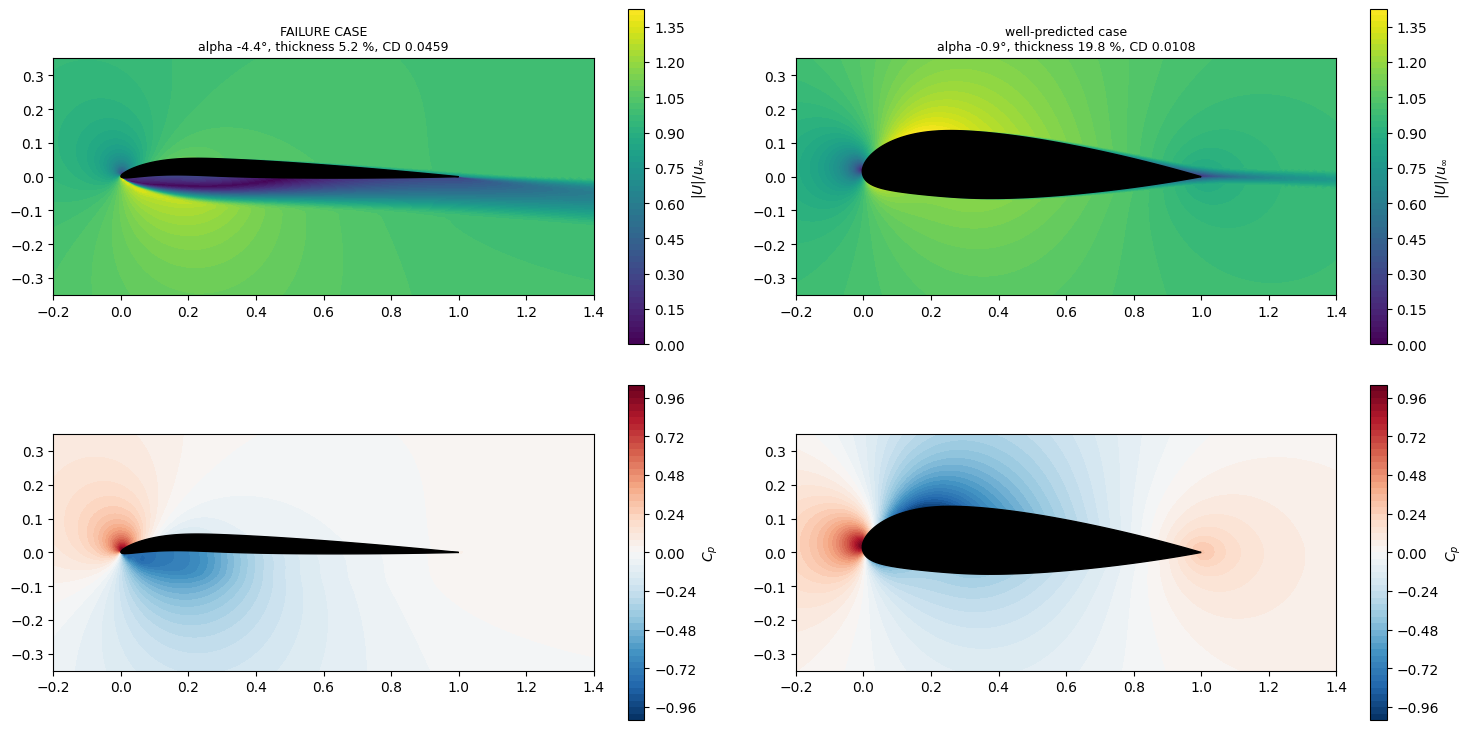

In [ ]:
sim = af.Simulation(root=ROOT, name=worst['name'])
u, aoa, naca = parse_name(worst['name'])
arr = np.concatenate([sim.position, sim.sdf, sim.normals, sim.velocity, sim.pressure,
                      sim.surface.reshape(-1, 1)], axis=-1)
pos, surf = arr[:, :2], arr[:, -1] > 0.5
q = 0.5 * u ** 2
import matplotlib.tri as mtri
from matplotlib.path import Path
tri = mtri.Triangulation(pos[:, 0], pos[:, 1])
sidx, n_up = order_surface(pos[surf], arr[surf, 3:5])
outline = pos[surf][sidx]
tri.set_mask(Path(outline).contains_points(pos[tri.triangles].mean(axis=1)))

# A well-predicted case at similar incidence, for contrast
ref_case = tf[(tf['aoa'] < 2) & (tf['err'] < tf['err'].median())].nsmallest(1, 'err').iloc[0]
sim_r = af.Simulation(root=ROOT, name=ref_case['name'])
u_r, aoa_r, _ = parse_name(ref_case['name'])

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for col, (S_, nm, uu, aa) in enumerate(((sim, worst['name'], u, aoa), (sim_r, ref_case['name'], u_r, aoa_r))):
    p_ = S_.position; s_ = S_.surface.ravel() > 0.5
    t_ = mtri.Triangulation(p_[:, 0], p_[:, 1])
    si, nu_ = order_surface(p_[s_], S_.normals[s_])
    ol = p_[s_][si]
    t_.set_mask(Path(ol).contains_points(p_[t_.triangles].mean(axis=1)))
    for row, (F, lab, cmap) in enumerate(((np.hypot(*S_.velocity.T) / uu, '$|U| / u_\\infty$', 'viridis'),
                                          (S_.pressure.ravel() / (0.5 * uu ** 2), '$C_p$', 'RdBu_r'))):
        a = axes[row, col]
        cf = a.tricontourf(t_, F, levels=60, cmap=cmap)
        a.fill(ol[:, 0], ol[:, 1], color='k')
        a.set_xlim(-0.2, 1.4); a.set_ylim(-0.35, 0.35); a.set_aspect('equal')
        plt.colorbar(cf, ax=a, label=lab, shrink=0.85)
    axes[0, col].set_title(f"{'FAILURE CASE' if col == 0 else 'well-predicted case'}\n"
                           f"alpha {aa:.1f}°, thickness {parse_name(nm)[2][-1]:.1f} %, "
                           f"CD {(worst if col == 0 else ref_case)['true_cd']:.4f}", fontsize=9)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/failure_case.png', dpi=150, bbox_inches='tight'); plt.show()

If the drag rise is caused by **flow separation**, the velocity field will show a thick low-speed region along one surface, and the pressure distribution will flatten where the flow has detached, instead of recovering smoothly towards the trailing edge. In that case the drag is set by a flow mechanism absent from the rest of the training data, while nothing in the design variables marks the case as unusual. That combination, an ordinary-looking design in an unrepresented flow regime, is what a data-driven surrogate cannot anticipate.

## 9. Trust verdict

In [ ]:
verdict = pd.DataFrame([
    dict(check='distance of optima from training designs',
         evidence=f"nearest {nn_dist(np.asarray(optima['p1_grad'], dtype=float))[0]:.3f} of the design range "
                  f"(typical spacing between training designs {np.median(own):.3f})"),
    dict(check='GP uncertainty at the optimum',
         evidence=f"sd(log CD) {pos_rows[0]['gp_sd_logCD']:.4f} vs {position.loc['design box (median)', 'gp_sd_logCD']:.4f} "
                  f"median over the design box"),
    dict(check='stability under retraining (problem 1)',
         evidence=f"L/D {sub['LD1'].mean():.2f} +/- {sub['LD1'].std():.2f}; "
                  f"thickness always at the {OPT['t_min']:.0f} % bound: {bool((sub['XX1'] <= OPT['t_min'] + 1e-6).all())}"),
    dict(check='stability under retraining (problem 2)',
         evidence=f"CD {sub['CD2'].mean():.5f} +/- {sub['CD2'].std():.5f}"),
    dict(check='agreement of independent surrogates at the optimum',
         evidence=f"ensemble L/D {ld_full:.2f} vs GP "
                  f"{(lambda c: c[0][0] / c[1][0])(gp_np(np.r_[np.asarray(optima['p1_grad'], dtype=float)[:3], OPT['aoa_p1']][None, :])[:2]):.2f}"),
    dict(check='behaviour outside a narrowed training band',
         evidence='; '.join(f"{v.split()[0]}: error/sd {band_table.loc[(v, g), 'err_over_sd']:.1f} ({g})"
                            for v, g in band_table.index if 'far' in g) or 'see section 7b'),
    dict(check='worst-predicted training case',
         evidence=f"{worst['family']}, thickness {parse_name(worst['name'])[2][-1]:.1f} %, alpha {worst['aoa']:.1f}°: "
                  f"drag {'under' if worst['gp_cd'] < worst['true_cd'] else 'over'}-predicted by "
                  f"{abs(1 - worst['gp_cd'] / worst['true_cd']) * 100:.0f} %, at "
                  f"{worst['err'] / worst['gp_sd_logcd']:.0f}x the predicted uncertainty"),
]).set_index('check')
print(verdict.to_string())

summary = dict(trust=TRUST,
               optima=dict(problem1=np.asarray(optima['p1_grad'], dtype=float).tolist(),
                           problem2=np.asarray(optima['p2_grad'], dtype=float).tolist()),
               position=position.reset_index().to_dict(orient='records'),
               resampling=sub.to_dict(orient='records'),
               agreement=agree.reset_index().to_dict(orient='records'),
               degradation=degr.reset_index().to_dict(orient='records'),
               controlled_extrapolation=band_table.reset_index().to_dict(orient='records'),
               failure_case=dict(name=str(worst['name']), true_cd=float(worst['true_cd']),
                                 gp_cd=float(worst['gp_cd']), sd_logcd=float(worst['gp_sd_logcd'])))
with open(f'{OUT_DIR}/phase4_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=float)
sub.to_csv(f'{OUT_DIR}/resampling_optima.csv', index=False)
ev.to_csv(f'{OUT_DIR}/envelope_evaluation.csv', index=False)
for p in sorted(glob.glob(f'{OUT_DIR}/*')):
    print(f'{os.path.getsize(p) / 1e6:8.2f} MB  {p}')

                                                                                                                                                  evidence
check                                                                                                                                                     
distance of optima from training designs                                nearest 0.130 of the design range (typical spacing between training designs 0.158)
GP uncertainty at the optimum                                                                       sd(log CD) 0.0114 vs 0.0070 median over the design box
stability under retraining (problem 1)                                                        L/D 93.80 +/- 1.56; thickness always at the 12 % bound: True
stability under retraining (problem 2)                                                                                              CD 0.00990 +/- 0.00011
agreement of independent surrogates at the optimum                    

## Summary
The optimised designs are assessed without new high-fidelity data, using four independent checks: their position relative to the training designs and the predicted uncertainty there; the stability of the optimum when the surrogate is retrained on random subsets; the growth of error against the growth of predicted uncertainty on the benchmark's Reynolds-number and angle-of-attack extrapolation splits; and the worst-predicted case in the training data, examined in detail, where the drag mechanism is absent from the rest of the data and the surrogate stays confident regardless.

**Conclusion.** A cheap data-driven surrogate narrows a design space quickly: both optimization problems were solved in seconds, to within a fraction of a percent of the surrogate's own optimum. What it cannot do is certify the result. The disagreement between two surrogates trained on the same data, and the movement of the optimum when that data is resampled, both exceed the improvements the optimizer is chasing, and confidence falls away outside the training envelope. The defensible use is therefore mixed-fidelity: surrogate-based exploration to find candidate designs, followed by high-fidelity verification and, if a gradient-based refinement is wanted at the high-fidelity level, an adjoint formulation, whose cost is essentially independent of the number of design variables.

**Results.** The problem-1 optimum's nearest training design is 0.130 away in normalised design
units, closer than the median spacing between training designs themselves (0.158), with a predicted
drag interval of ±2.3 %. It is interpolation, not extrapolation.

Retraining on eight random 80 % subsets and re-optimising gives L/D = 93.8 ± 1.6 and
lift-constrained drag 0.0099 ± 0.0001, but the designs move substantially: camber from 4.8 to 7.0 and
camber position from 4.2 to 6.9, some 14–20 % of the design range, with thickness on the 12 % bound
in every run. Evaluated at the fixed full-data optimum, the retrained surrogates predict
L/D = 93.3 ± 1.9. The surrogate therefore identifies a *family* of near-equivalent designs rather
than a unique optimum, and the spread between surrogates exceeds the differences the optimizer
resolves.

Narrowing the training band deliberately and testing outside it:

| band narrowed in | inside | near outside | far outside | error / predicted σ, far |
|---|---|---|---|---|
| Reynolds number | 0.8 % | 1.3 % | 2.4 % | 0.89 |
| angle of attack | 0.3 % | 0.5 % | 4.0 % | 1.60 |

Predicted uncertainty grows roughly in step with the error, so it is a usable stopping signal near
the edge of the data. On the benchmark's `reynolds` and `aoa` splits (397 cases after removing 88
that belong to this model's training set) drag errors stay between 0.3 % and 0.8 % with rank
correlations of 0.985 to 0.999, and 84–90 % of cases fall within ±2σ against an ideal 95 %.

The exception is decisive. The worst-predicted case is a 5.2 %-thick airfoil at −4.4° incidence
whose flow separates along the lower surface, visible in the velocity field as a low-speed region
reaching the trailing edge. Its drag is 4.1× the training median and 93 % of it is pressure drag,
against 33 % typically; the surrogate under-predicts it by 80 %, at **139× the predicted
uncertainty**. Only 7 of 200 training cases lie in that region of the design space, and an optimizer
minimising drag is drawn towards exactly this direction, since thin sections have low drag while the
flow stays attached.

The distinction this draws is the main conclusion. Predicted uncertainty measures distance from the
data in input space and behaves well there; it is blind to a change of flow regime, because the
inputs look unremarkable. A surrogate's confidence bounds its interpolation error, not its physics
error, and only high-fidelity verification covers the difference. The minimum-thickness constraint
that makes the design problem physically sensible also, and not coincidentally, keeps the surrogate
inside its valid regime.